# Классификация: IC50 выше медианы

В данном ноутбуке решается задача бинарной классификации.

Цель - предсказать, превышает ли значение IC50 медианное значение выборки.

Такой подход позволяет перейти от точного предсказания численного значения IC50 к более простой и практичной задаче разделения соединений на две группы.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Загрузка данных

In [2]:
df = pd.read_excel("../data/compounds.xlsx")

df = df.drop(
    columns=[col for col in df.columns if "Unnamed" in col],
    errors="ignore"
)

df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


# Создание целевой переменной

Для классификации используется бинарный признак: превышает ли IC50 медианное значение.

Так как порогом является медиана, классы должны быть примерно сбалансированы.

In [3]:
target = "IC50, mM"

median_value = df[target].median()

y = (df[target] > median_value).astype(int)

median_value

np.float64(46.58518345980803)

In [4]:
y.value_counts(normalize=True)

IC50, mM
0    0.5005
1    0.4995
Name: proportion, dtype: float64

Классы получились примерно сбалансированными, так как порог выбран по медиане. Это удобно для обучения моделей и позволяет использовать accuracy наряду с precision, recall и F1.

# Подготовка признаков

In [5]:
X = df.drop(
    columns=["IC50, mM", "CC50, mM", "SI"],
    errors="ignore"
)

X = X.select_dtypes(include=["number"])

X.shape

(1001, 210)

Из признакового пространства исключаются IC50, CC50 и SI, так как они являются целевыми показателями.

В качестве признаков используются только числовые характеристики химических соединений.

# Разделение данных

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Метрики качества

Для оценки моделей используются accuracy, precision, recall, F1 и ROC-AUC.

Так как классы по медиане примерно сбалансированы, accuracy является полезной метрикой. Однако для более полной оценки также используются F1 и ROC-AUC.

In [7]:
def classification_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba)
    }

# Baseline модель

В качестве baseline используется DummyClassifier, который предсказывает наиболее частый класс.

Это позволяет проверить, действительно ли ML-модели находят полезные закономерности.

In [8]:
dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_proba_dummy = np.zeros_like(y_pred_dummy, dtype=float)

baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_dummy),
    "precision": precision_score(y_test, y_pred_dummy, zero_division=0),
    "recall": recall_score(y_test, y_pred_dummy, zero_division=0),
    "f1": f1_score(y_test, y_pred_dummy, zero_division=0),
    "roc_auc": 0.5,
    "model": "DummyClassifier"
}

baseline_metrics

{'accuracy': 0.5024875621890548,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.5,
 'model': 'DummyClassifier'}

Baseline-модель DummyClassifier предсказывает наиболее частый класс и не использует признаки объектов.

Так как целевая переменная построена относительно медианы IC50, классы получились почти сбалансированными, поэтому accuracy baseline находится около 0.5.

Precision, recall и F1 равны 0, так как DummyClassifier предсказывает только один класс и не выделяет объекты с IC50 выше медианы.

Таким образом, baseline соответствует почти случайному разделению и используется как нижняя граница качества для сравнения с ML-моделями.

# Сравнение моделей

Для решения задачи сравним несколько типов моделей:
- логистическую регрессию
- метод ближайших соседей
- решающее дерево
- ансамбли деревьев
- бустинговые модели

Это позволит понять, какие алгоритмы лучше подходят для разделения соединений по уровню IC50.

In [9]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42)
}

In [10]:
results = []

for name, model in models.items():

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred

    metrics = classification_metrics(
        y_test,
        y_pred,
        y_proba
    )

    metrics["model"] = name

    results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "f1",
    ascending=False
)

results_df

,accuracy,precision,recall,f1,roc_auc,model
3,0.696517,0.669565,0.77,0.716279,0.767723,RandomForest
4,0.701493,0.681818,0.75,0.714286,0.727030,ExtraTrees
5,0.691542,0.666667,0.76,0.710280,0.773168,GradientBoosting
6,0.686567,0.666667,0.74,0.701422,0.754901,HistGradientBoosting
0,0.681592,0.657895,0.75,0.700935,0.748465,LogisticRegression
1,0.691542,0.682692,0.71,0.696078,0.751733,KNN
2,0.646766,0.643564,0.65,0.646766,0.663614,DecisionTree


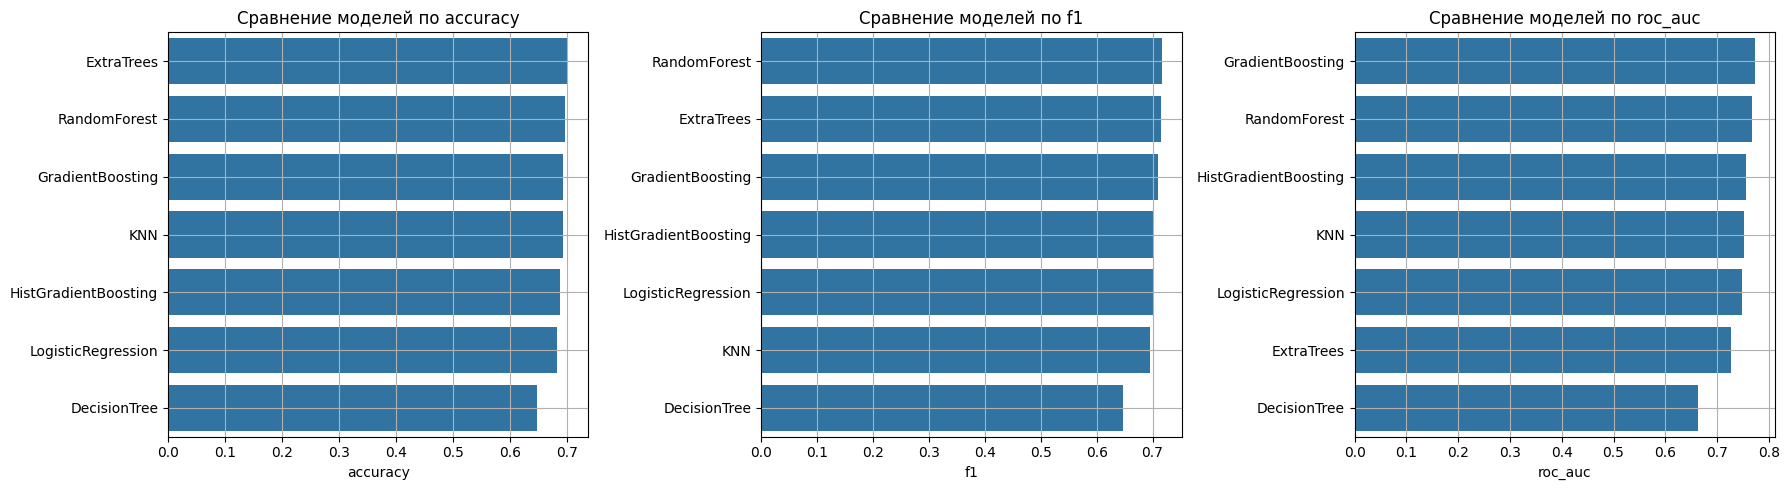

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_names = ["accuracy", "f1", "roc_auc"]

for i, metric in enumerate(metrics_names):
    sns.barplot(
        data=results_df.sort_values(metric,ascending=False),
        x=metric,
        y="model",
        ax=axes[i]
    )

    axes[i].set_title(f"Сравнение моделей по {metric}")
    axes[i].set_ylabel("")
    axes[i].grid()

plt.tight_layout()
plt.show()

Сравнение моделей показало, что все рассмотренные алгоритмы заметно превосходят baseline-модель.

Наилучший результат по F1 показала модель RandomForestClassifier. Также близкое качество продемонстрировали ExtraTreesClassifier и GradientBoostingClassifier.

Интересно, что LogisticRegression также показала достаточно высокий результат. Это говорит о том, что задача классификации относительно медианы проще, чем задача точной регрессии IC50.

В целом ансамблевые методы остаются наиболее устойчивыми, однако разница между несколькими лучшими моделями невелика.

# Подбор гиперпараметров

После первичного сравнения моделей выполним подбор гиперпараметров для наиболее перспективных алгоритмов.

В качестве основной метрики используется F1, так как она учитывает баланс между precision и recall.

In [12]:
param_grids = {
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        }
    },
    "ExtraTrees": {
        "model": ExtraTreesClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3, 5]
        }
    }
}

In [13]:
top_models = results_df["model"].head(3).tolist()

grid_results = []

best_model = None
best_score = -np.inf
best_model_name = None

for name in top_models:

    if name not in param_grids:
        continue

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("model", param_grids[name]["model"])
    ])

    grid = GridSearchCV(
        pipe,
        param_grids[name]["params"],
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    grid_results.append({
        "model": name,
        "best_f1_cv": grid.best_score_,
        "best_params": grid.best_params_
    })

    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_model = grid.best_estimator_
        best_model_name = name

grid_results_df = pd.DataFrame(grid_results)

grid_results_df.sort_values(
    "best_f1_cv",
    ascending=False
)

,model,best_f1_cv,best_params
1,ExtraTrees,0.740790,"{'model__max_depth': 10, 'model__min_samples_l..."
0,RandomForest,0.739603,"{'model__max_depth': 10, 'model__min_samples_l..."
2,GradientBoosting,0.729667,"{'model__learning_rate': 0.05, 'model__max_dep..."


# Оценка лучшей модели

In [14]:
best_model_name

'ExtraTrees'

In [15]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

best_metrics = classification_metrics(
    y_test,
    y_pred,
    y_proba
)

best_metrics

{'accuracy': 0.7213930348258707,
 'precision': 0.6929824561403509,
 'recall': 0.79,
 'f1': 0.7383177570093458,
 'roc_auc': 0.7855940594059406}

После подбора гиперпараметров лучшей моделью стала ExtraTreesClassifier.

По сравнению с первичным сравнением моделей качество улучшилось: значение F1 увеличилось, а ROC-AUC стал выше.

Модель показывает хороший recall, то есть достаточно хорошо находит соединения, у которых IC50 превышает медианное значение. При этом precision также остается на приемлемом уровне.

Таким образом, ExtraTreesClassifier был выбран в качестве финальной модели для задачи классификации IC50 относительно медианы.

# Матрица ошибок

Матрица ошибок показывает, сколько объектов каждого класса модель классифицировала правильно и неправильно.

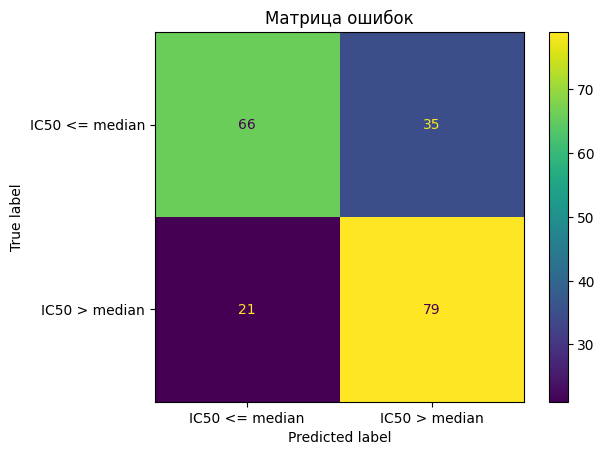

In [16]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["IC50 <= median", "IC50 > median"]
)

disp.plot()

plt.title("Матрица ошибок")
plt.show()

Матрица ошибок показывает, что модель достаточно хорошо разделяет соединения по значению IC50 относительно медианы.

Модель правильно классифицировала 66 объектов класса IC50 <= median и 79 объектов класса IC50 > median.

При этом модель допустила 35 ложноположительных ошибок и 21 ложноотрицательную ошибку. Это означает, что модель чаще ошибочно относит соединения к классу IC50 > median, чем пропускает объекты этого класса.

Высокий recall показывает, что модель хорошо находит соединения с IC50 выше медианы. Однако precision ниже recall, поэтому часть предсказаний положительного класса оказывается ошибочной.

В целом матрица ошибок подтверждает, что модель работает заметно лучше baseline и достаточно устойчиво решает задачу бинарной классификации.

# ROC-кривая

ROC-кривая показывает способность модели разделять два класса при разных порогах классификации.

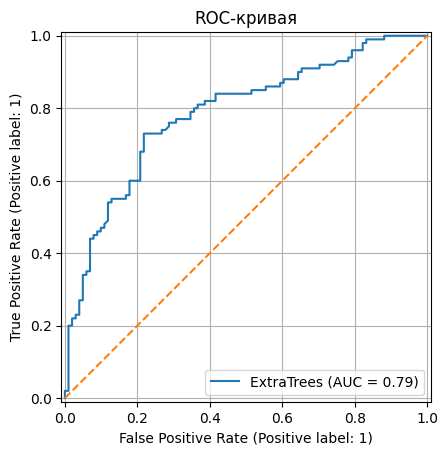

In [17]:
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    name=best_model_name
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC-кривая")
plt.grid()
plt.show()

ROC-кривая показывает, что модель хорошо отделяет соединения с IC50 выше медианы от остальных.

Значение AUC составляет около 0.79, что заметно выше случайного уровня 0.5. Это подтверждает, что модель не просто угадывает класс, а использует полезную информацию из признаков.

Вместе с результатами матрицы ошибок это показывает, что финальная модель достаточно устойчиво решает задачу бинарной классификации IC50 относительно медианы.

# Анализ важности признаков

Рассмотрим, какие признаки оказались наиболее важными для классификации IC50 относительно медианы.

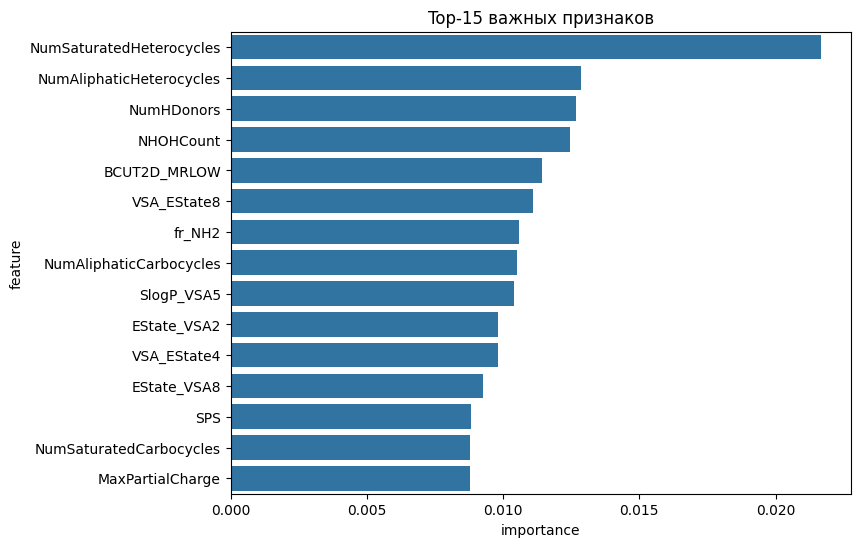

In [18]:
model = best_model.named_steps["model"]

if hasattr(model, "feature_importances_"):

    feature_names = X.columns

    if "variance" in best_model.named_steps:

        mask = best_model.named_steps["variance"].get_support()

        feature_names = feature_names[mask]

    importances = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    })

    importances = importances.sort_values(
        "importance",
        ascending=False
    ).head(15)

    plt.figure(figsize=(8, 6))

    sns.barplot(
        data=importances,
        x="importance",
        y="feature"
    )

    plt.title("Top-15 важных признаков")

    plt.show()

Анализ важности признаков показывает, что модель использует сразу несколько химических характеристик для классификации соединений по IC50 относительно медианы.

Наиболее важным признаком оказался NumSaturatedHeterocycles. Также заметный вклад вносят признаки NumAliphaticHeterocycles, NumHDonors, NHOHCount, BCUT2D_MRLOW и VSA_EState8.

Это говорит о том, что модель опирается на структурные и физико-химические дескрипторы молекул, а не на один отдельный показатель.

Важно отметить, что высокая importance не означает причинно-следственную связь. Она показывает только то, что данный признак оказался полезным для выбранной модели при решении задачи классификации.

Часть важных признаков пересекается с задачей регрессии IC50, что подтверждает устойчивость найденных закономерностей.

# Выводы

В рамках задачи была построена модель бинарной классификации для определения того, превышает ли значение IC50 медианное значение выборки.

Целевая переменная была сформирована на основе медианы IC50. Благодаря этому классы получились почти сбалансированными, что позволило использовать accuracy, precision, recall, F1 и ROC-AUC для оценки качества моделей.

Baseline-модель DummyClassifier показала accuracy около 0.5 и ROC-AUC 0.5, что соответствует почти случайному угадыванию. Все основные ML-модели заметно превзошли baseline, значит химические признаки действительно содержат полезную информацию для разделения соединений по IC50.

На первичном сравнении лучшие результаты показали ансамблевые методы, особенно RandomForestClassifier, ExtraTreesClassifier и GradientBoostingClassifier. При этом LogisticRegression также показала неплохое качество, что говорит о том, что задача классификации относительно медианы проще, чем точная регрессия IC50.

После подбора гиперпараметров лучшей моделью стала ExtraTreesClassifier. Финальная модель показала accuracy около 0.72, F1 около 0.74 и ROC-AUC около 0.79.

Матрица ошибок показала, что модель правильно классифицировала 66 объектов класса IC50 <= median и 79 объектов класса IC50 > median. Модель лучше находит соединения с IC50 выше медианы, что подтверждается высоким recall. При этом часть объектов ошибочно относится к положительному классу, поэтому precision немного ниже recall.

ROC-кривая также подтверждает хорошее качество модели: значение AUC около 0.79 заметно выше случайного уровня 0.5.

Анализ важности признаков показал, что модель использует несколько химических характеристик соединений. Наиболее важными оказались NumSaturatedHeterocycles, NumAliphaticHeterocycles, NumHDonors, NHOHCount, BCUT2D_MRLOW и VSA_EState8. Это говорит о том, что модель опирается на структурные и физико-химические дескрипторы молекул, а не на один отдельный признак.

Таким образом, задача классификации IC50 относительно медианы решается достаточно устойчиво. Лучшей моделью в рамках проведённых экспериментов стала ExtraTreesClassifier, которая показала хороший баланс между точностью, полнотой и общей способностью разделять два класса.